# Chapter 5c -- Biodiversity as an asset class II: species-abundance & community-ecology models

Second of three notebooks on this biodiversity/natural-capital case study
(the previous notebook covered extinction theory and island biogeography;
the next continues with land use, food systems and forestry). This one is
about how ecologists actually characterize a community's diversity from
field-survey data: species-abundance distributions (how many species are
common vs. rare), classic theoretical models of that distribution shape,
how species counts accumulate as more area/individuals are sampled, and
the species-area/endemics-area relationships that connect a survey plot's
size to how many species (and how many endemics) it's expected to contain.

An alternate flat-color rendering of the habitat-loss/fragmentation
schematic below is not built as a separate figure.

Three helper functions this analysis needs
(`species_abundance_distribution`, `species_area_relationship`,
`endemics_area_relationship`) aren't available as ready-made
implementations, so they're reimplemented below from the standard
ecological models they're named after and cross-checked against
closed-form formulas that hold for special cases (e.g. the "even"
species-area model): a random-placement (Coleman 1981) model for the
species-area/endemics-area relationships, confirmed exactly against the
even-abundance closed form, and a standard doubling ("octave")
abundance-binning scheme for the abundance distribution, whose exact bin
convention couldn't be independently verified against a reference
implementation and is flagged where used.

Three sections read real community-ecology survey data shipped in this
repo's `Data/` folder (Whittaker's Siskiyou Mountains vegetation survey,
Verneaux's Doubs river fish survey, and Condit's Barro Colorado Island
forest census) via `pandas.read_excel`.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.optimize import minimize_scalar
from scipy.stats import lognorm
from scipy.special import gammaln

from quanttoolbox.sustainable_finance.ecology import (
    species_abundance_distribution as _tb_species_abundance_distribution,
    species_area_relationship as _tb_species_area_relationship,
    endemics_area_relationship as _tb_endemics_area_relationship,
    hurlbert as _tb_hurlbert,
)

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

DATA_DIR = "../../data"


# Thin wrapper around quanttoolbox's own species_abundance_distribution
# (whose octave/custom-array binning convention was fixed earlier against
# this exact notebook's data -- see the toolbox docstring). Verified
# numerically identical (values and dtype) to this notebook's own former
# hand-rolled implementation on all real datasets/modes used below.
#   n_i: per-species abundance counts.
#   brk=None:      returns (j, s) = distinct abundance values and species count at each.
#   brk='octave':  returns (k, s, edges) = doubling-octave index, species count per
#                  octave, and each octave's upper abundance boundary (2**(k+1)).
#   brk=array:     returns (edges, s) = the given bin upper-edges (first bin is
#                  (0, edges[0]]) and species count per bin.
def species_abundance_distribution(n_i, brk=None):
    n_i = np.asarray(n_i, dtype=float)
    if brk is None:
        j, s, _ = _tb_species_abundance_distribution(n_i)
        return j, s.astype(int)
    if isinstance(brk, str) and brk.lower() == "octave":
        k, s, edges = _tb_species_abundance_distribution(n_i, "octave")
        return k.astype(int), s.astype(int), edges
    brk = np.asarray(brk, dtype=float)
    _, s, _ = _tb_species_abundance_distribution(n_i, brk)
    return brk, s.astype(int)


# Random-placement (Coleman 1981) species-area curve: probability a species
# with n individuals is absent from a randomly located sub-area a is (1-a/A)**n,
# so expected richness is S(a) = sum_i [1 - (1-a/A)**n_i]. Accepts either raw
# per-species abundances n_i or an abundance distribution s_j (species count at
# abundance j=1,2,...).
def species_area_relationship(n_i=None, s_j=None, A=None, a=None):
    # Thin wrapper around quanttoolbox's own species_area_relationship, which
    # implements the same random-placement formula; verified numerically
    # identical on this notebook's data.
    return np.atleast_1d(_tb_species_area_relationship(n_i, s_j, A, a))


# Random-placement (Coleman 1981) endemics-area curve: probability all n
# individuals of a species fall inside sub-area a is (a/A)**n, so expected
# endemic richness is E(a) = sum_i (a/A)**n_i.
def endemics_area_relationship(n_i=None, s_j=None, A=None, a=None):
    # Thin wrapper around quanttoolbox's own endemics_area_relationship;
    # verified numerically identical on this notebook's data.
    return np.atleast_1d(_tb_endemics_area_relationship(n_i, s_j, A, a))


# Hurlbert (1971) individual-based rarefaction: expected number of species
# in a random sample of m individuals drawn without replacement from a
# community with per-species abundances n_i (total N = sum(n_i)).
# E[S(m)] = S - sum_i C(N-n_i, m) / C(N, m), computed in log-space.
def hurlbert_rarefaction(n_i, m):
    n_i = np.asarray(n_i, dtype=float)
    N = n_i.sum()
    if m > N:
        return np.nan
    return _tb_hurlbert(n_i, m, method=2)


## 1. Habitat degradation: a schematic

Four stylized ways habitat can be lost or degraded as a
conservation/impact-measurement matter: outright habitat loss,
fragmentation into smaller disconnected patches, and degradation
(quality decline without area loss).


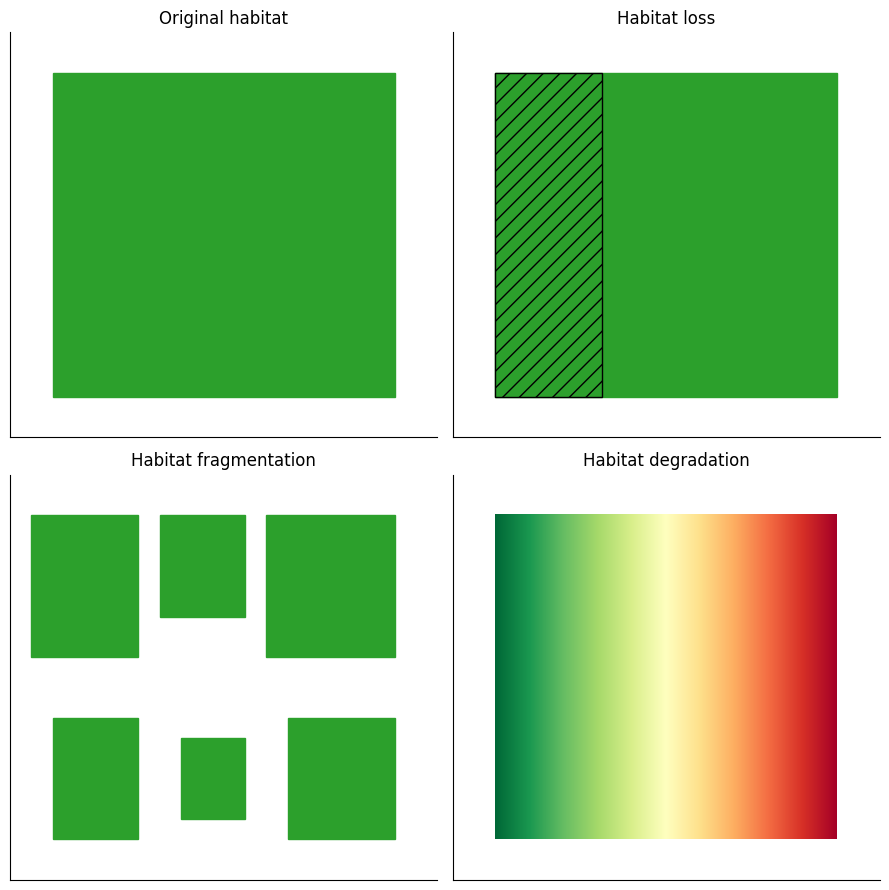

In [2]:

fig, axes = plt.subplots(2, 2, figsize=(9, 9))

# Original habitat
axes[0, 0].add_patch(mpatches.Rectangle((0.1, 0.1), 0.8, 0.8, color="tab:green"))
axes[0, 0].set_title("Original habitat")

# Habitat loss
axes[0, 1].add_patch(mpatches.Rectangle((0.1, 0.1), 0.8, 0.8, color="tab:green"))
axes[0, 1].add_patch(mpatches.Rectangle((0.1, 0.1), 0.25, 0.8, facecolor="none", edgecolor="black", hatch="//"))
axes[0, 1].set_title("Habitat loss")

# Habitat fragmentation
rng = np.random.default_rng(0)
patches = [(0.05, 0.55, 0.25, 0.35), (0.35, 0.65, 0.20, 0.25), (0.60, 0.55, 0.30, 0.35),
           (0.10, 0.10, 0.20, 0.30), (0.40, 0.15, 0.15, 0.20), (0.65, 0.10, 0.25, 0.30)]
for (x, y, w, h) in patches:
    axes[1, 0].add_patch(mpatches.Rectangle((x, y), w, h, color="tab:green"))
axes[1, 0].set_title("Habitat fragmentation")

# Habitat degradation (quality gradient, same footprint)
grad = np.linspace(0, 1, 256).reshape(1, -1)
axes[1, 1].imshow(grad, extent=(0.1, 0.9, 0.1, 0.9), cmap="RdYlGn_r", aspect="auto")
axes[1, 1].set_title("Habitat degradation")

for ax in axes.flat:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()


## 2. Species-abundance distributions

A community's species-abundance distribution -- how many species are
represented by 1 individual, 2 individuals, and so on -- is a core
descriptor of diversity, independent of any spatial/area information.


### 2.1 A small illustrative community

25 species with abundances ranging from singletons to 117 individuals,
summarized three ways: the raw abundance-frequency table, a custom-binned
histogram, and species ranked by abundance with their cumulative share of
all individuals.


In [3]:

n_i = np.array([2, 10, 13, 2, 1, 5, 25, 17, 1, 4, 28, 117, 23, 10, 13, 1, 4, 3, 10, 5,
                 7, 70, 10, 25, 1])
print(f"S = {len(n_i)} species, n = {n_i.sum()} individuals")

j, s = species_abundance_distribution(n_i)
pd.DataFrame({"Abundance j": j.astype(int), "Species s_j": s})


S = 25 species, n = 407 individuals


,Abundance j,Species s_j
0,1,4
1,2,2
2,3,1
3,4,2
4,5,2
5,7,1
6,10,4
7,13,2
8,17,1
9,23,1


In [4]:

brk = np.array([1, 2, 3, 4, 5, 10, 25, 50, 100, 200])
_, s_brk = species_abundance_distribution(n_i, brk)
pd.DataFrame({"Abundance <= ": brk, "Species": s_brk})


,Abundance <=,Species
0,1,0
1,2,4
2,3,2
3,4,1
4,5,2
5,10,3
6,25,8
7,50,3
8,100,1
9,200,1


In [5]:

order = np.argsort(-n_i)
n_k = n_i[order]
f_k = n_k / n_i.sum()
rank_table = pd.DataFrame({
    "Rank k": np.arange(1, len(n_i) + 1),
    "Species (original index)": order + 1,
    "n_k": n_k,
    "f_k (%)": 100 * f_k,
    "Cumulative (%)": 100 * np.cumsum(f_k),
})
rank_table.round(2)


,Rank k,Species (original index),n_k,f_k (%),Cumulative (%)
0,1,12,117,28.75,28.75
1,2,22,70,17.20,45.95
2,3,11,28,6.88,52.83
3,4,7,25,6.14,58.97
4,5,24,25,6.14,65.11
5,6,13,23,5.65,70.76
6,7,8,17,4.18,74.94
7,8,15,13,3.19,78.13
8,9,3,13,3.19,81.33
9,10,19,10,2.46,83.78


### 2.2 A real community: Whittaker's Siskiyou Mountains tree survey

Tree species abundances across the Siskiyou Mountains vegetation survey
plots (Whittaker 1960), read from
`chap5_biodiversity_whittaker_siskiyou.xlsx`.


S = 59 species, n = 41720 individuals


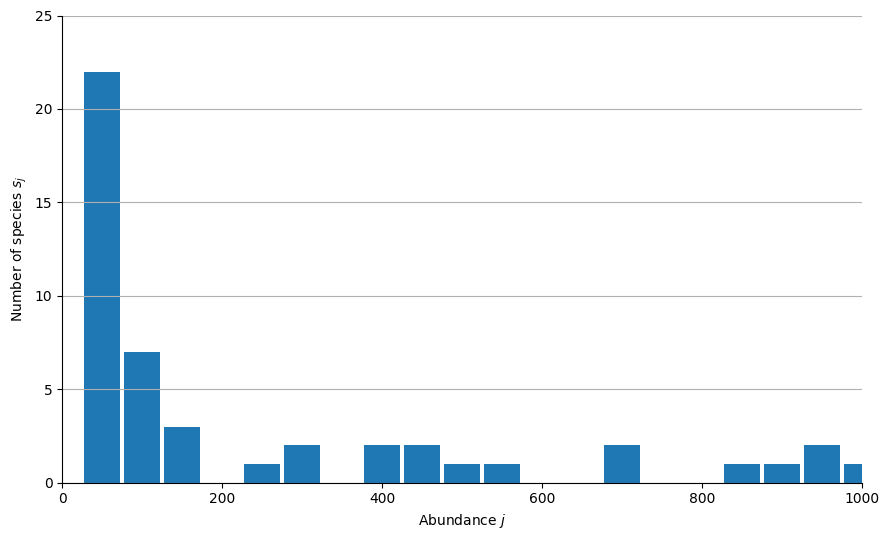

In [6]:

whittaker_trees = pd.read_excel(f"{DATA_DIR}/chap5_biodiversity_whittaker_siskiyou.xlsx", sheet_name="4_Tree_Data")
n_i_whittaker = whittaker_trees.groupby("Species_Name")["Total_Individuals"].sum()
print(f"S = {len(n_i_whittaker)} species, n = {n_i_whittaker.sum():.0f} individuals")

brk = np.arange(50, 1050, 50)
j, s = species_abundance_distribution(n_i_whittaker.values, brk)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(j, s, width=45, color="tab:blue")
ax.set_xlabel("Abundance $j$")
ax.set_ylabel("Number of species $s_j$")
ax.set_xlim(0, 1000)
ax.set_ylim(0, 25)
ax.grid(axis="y")
plt.tight_layout()


#### Rank-abundance curve

The same data as a Whittaker rank-abundance plot: species ranked from
most to least abundant against their share of all individuals, log scale.


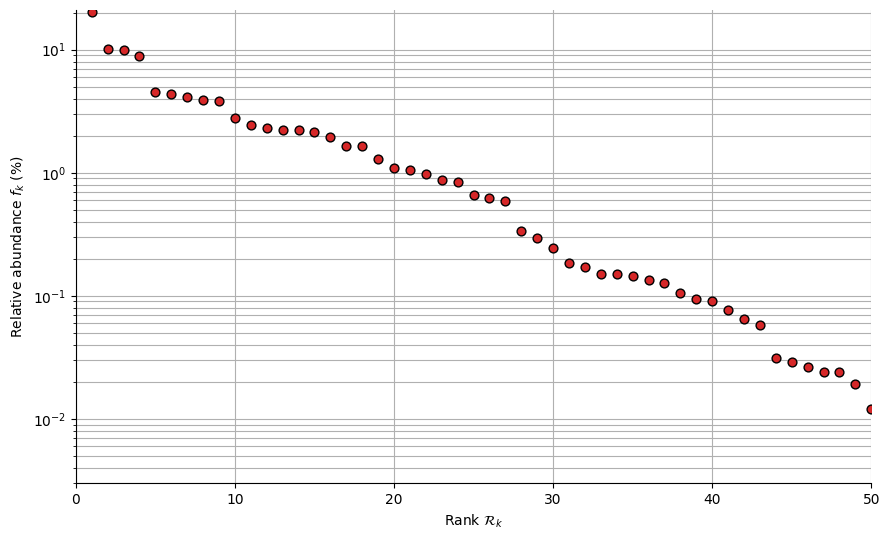

In [7]:

order = np.argsort(-n_i_whittaker.values)
n_k = n_i_whittaker.values[order]
f_k = 100 * n_k / n_k.sum()
k = np.arange(1, len(n_k) + 1)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(k, f_k, s=40, color="tab:red", edgecolor="black", zorder=3)
ax.set_yscale("log")
ax.set_xlabel("Rank $\\mathcal{R}_k$")
ax.set_ylabel("Relative abundance $f_k$ (%)")
ax.set_xlim(0, 50)
ax.set_ylim(0.003, 21)
ax.grid(True, which="both")
plt.tight_layout()


#### The five most abundant species


In [8]:

top5 = n_i_whittaker.sort_values(ascending=False).head(5)
top5.rename("Total individuals").to_frame()


,Total individuals
Species_Name,
Lithocarpus densiflorus,8439.0
Quercus chrysolepis,4207.0
Abies concolor,4172.0
Pseudotsuga menziesii var. menziesii,3725.0
Chrysolepis chrysophylla var. chrysophylla,1886.0


### 2.3 Octave (doubling) binning

A common alternative to fixed-width abundance bins is "octave" binning,
where each successive bin doubles in width (1, 2, [3-4], [5-8], [9-16],
...) -- this compresses the long right tail of rare-to-common species onto
a manageable number of bars, at the cost of coarser resolution among
common species.


In [9]:

k, s_k, edges = species_abundance_distribution(n_i, "octave")
pd.DataFrame({"Octave k": k, "Upper bound": edges.astype(int), "Species s_k": s_k})


,Octave k,Upper bound,Species s_k
0,0,2,4
1,1,4,3
2,2,8,5
3,3,16,6
4,4,32,5
5,5,64,0
6,6,128,2


#### Octave distribution, Whittaker's Siskiyou trees


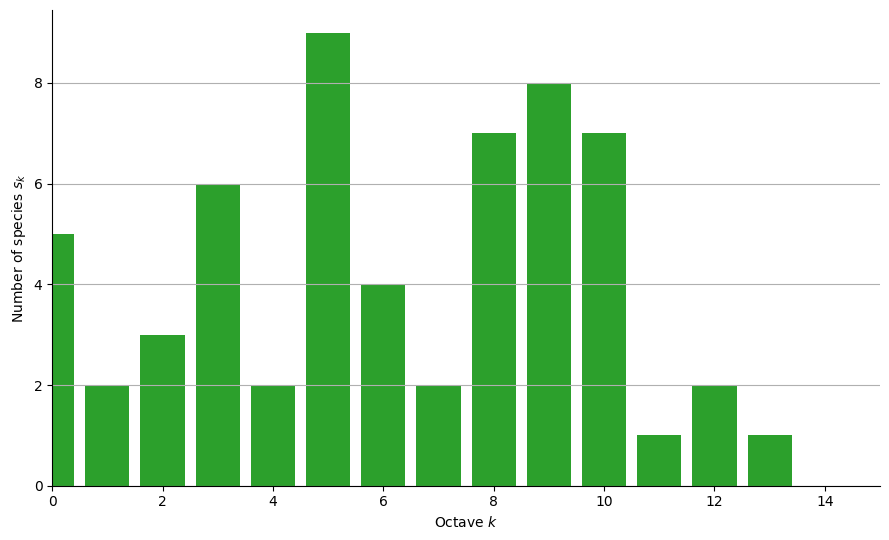

In [10]:

k, s_k, edges = species_abundance_distribution(n_i_whittaker.values, "octave")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(k, s_k, color="tab:green")
ax.set_xlabel("Octave $k$")
ax.set_ylabel("Number of species $s_k$")
ax.set_xlim(0, 15)
ax.grid(axis="y")
plt.tight_layout()


#### Octave distribution, Verneaux's Doubs river fish survey

Fish species abundances summed across 30 sampling sites along the river
Doubs, read from `chap5_biodiversity_verneaux_doubs.xlsx`.


S = 27 species, n = 1004 individuals


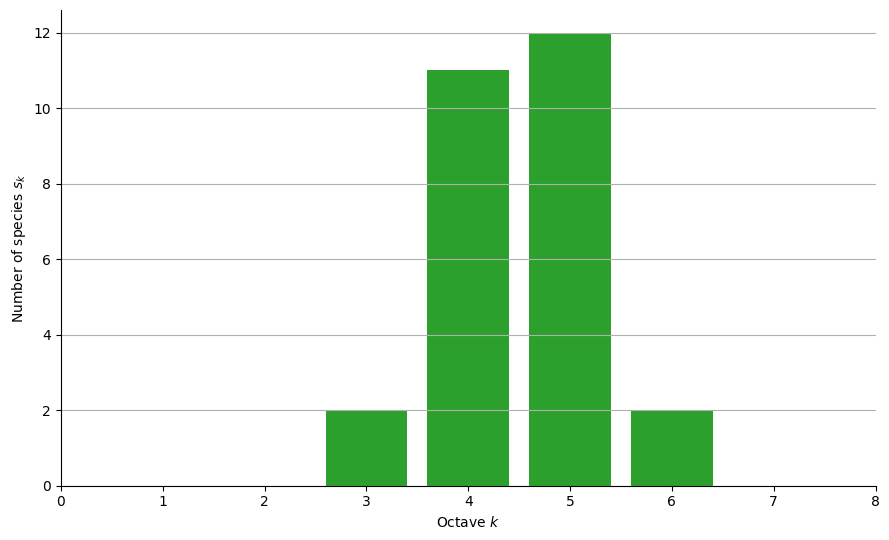

In [11]:

xl = pd.ExcelFile(f"{DATA_DIR}/chap5_biodiversity_verneaux_doubs.xlsx")
doubs_species = xl.parse("Species").set_index("site")
n_i_doubs = doubs_species.sum(axis=0)
n_i_doubs = n_i_doubs[n_i_doubs > 0]
print(f"S = {len(n_i_doubs)} species, n = {n_i_doubs.sum():.0f} individuals")

k, s_k, edges = species_abundance_distribution(n_i_doubs.values, "octave")

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(k, s_k, color="tab:green")
ax.set_xlabel("Octave $k$")
ax.set_ylabel("Number of species $s_k$")
ax.set_xlim(0, 8)
ax.grid(axis="y")
plt.tight_layout()


#### Octave distribution, Condit's Barro Colorado Island forest census

Tree species counts from the 50-hectare BCI forest plot (Condit et al.),
read from `chap5_biodiversity_condit_bci.xlsx` -- both the 50 standard BCI
census quadrats and the fuller extended dataset (additional
plots/transects in the same workbook) -- against a fitted log-normal
density.


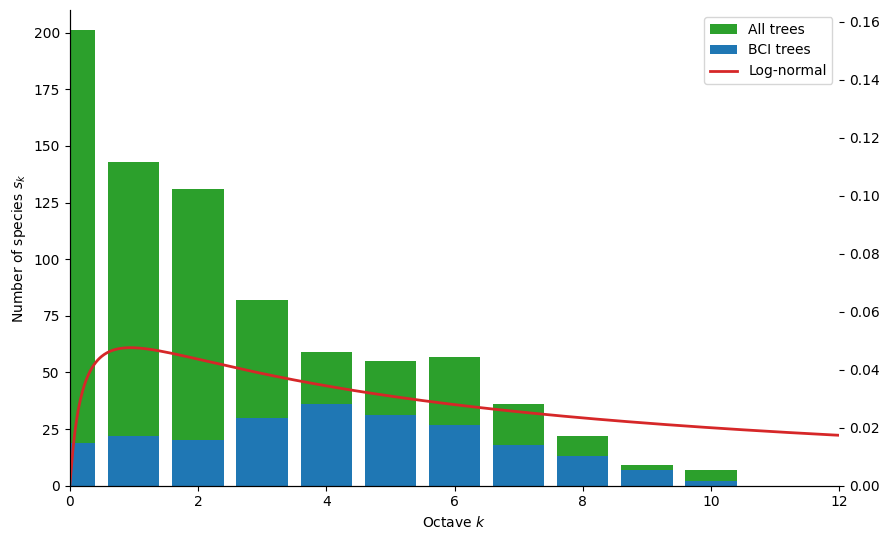

In [12]:

condit = pd.read_excel(f"{DATA_DIR}/chap5_biodiversity_condit_bci.xlsx", sheet_name="full matrix")
bci_cols = [c for c in condit.columns if c.startswith("BCI")]
n_i_bci = condit[bci_cols].sum(axis=1)
n_i_bci = n_i_bci[n_i_bci > 0].values
k1, s_k1, _ = species_abundance_distribution(n_i_bci, "octave")

all_cols = [c for c in condit.columns if c != "Species"]
n_i_all = condit[all_cols].sum(axis=1)
n_i_all = n_i_all[n_i_all > 0].values
k2, s_k2, _ = species_abundance_distribution(n_i_all, "octave")

log_n = np.log(n_i_bci)
mu_x, sigma_x = log_n.mean(), log_n.std(ddof=0)
x = np.concatenate([np.arange(0.001, 0.05, 0.001), np.arange(0.05, 1, 0.01), np.arange(1, 15, 0.1)])
pdf_x = lognorm.pdf(x, s=sigma_x, scale=np.exp(mu_x))

fig, ax1 = plt.subplots(figsize=(9, 5.5))
ax1.bar(k2, s_k2, color="tab:green", label="All trees")
ax1.bar(k1, s_k1, color="tab:blue", label="BCI trees")
ax1.set_xlabel("Octave $k$")
ax1.set_ylabel("Number of species $s_k$")
ax1.set_xlim(0, 12)
ax1.set_ylim(0, 210)

ax2 = ax1.twinx()
ax2.plot(x, pdf_x, color="tab:red", linewidth=2, label="Log-normal")
ax2.set_ylim(0, 0.164)
ax2.spines["top"].set_visible(False)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout()


## 3. Classic species-abundance model families

Four theoretical species-abundance distributions calibrated to the same
$S=15$ species, $n=80$ individuals community: the geometric series
(dominance-heavy), log-series, log-normal (the empirically best-supported
shape for most real communities), and the broken-stick (evenness-heavy)
model.


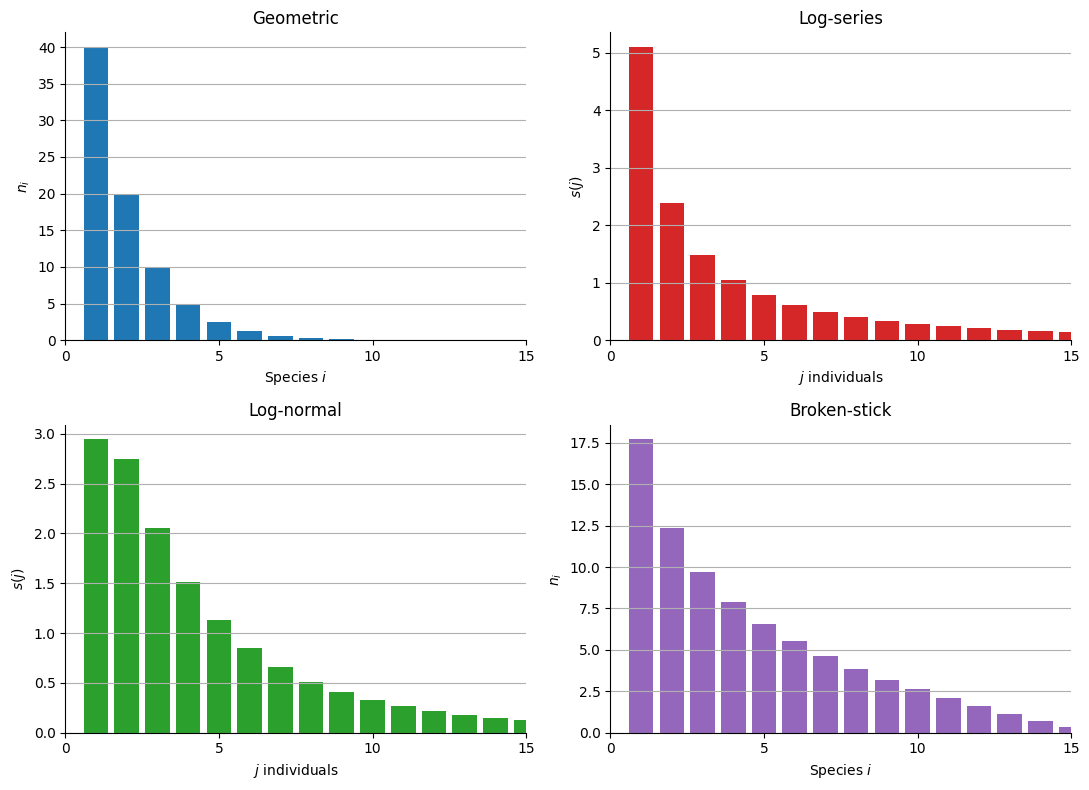

In [13]:

n, S = 80, 15

# Geometric series
kappa = 0.5
i = np.arange(1, S + 1)
n_i_geom = n * kappa * (1 - kappa) ** (i - 1) / (1 - (1 - kappa) ** S)

# Log-series
def diff2(alpha):
    return (S - alpha * np.log(1 + n / alpha)) ** 2
alpha = minimize_scalar(diff2, bounds=(0.01, 100), method="bounded").x
x_ls = n / (alpha + n)
j = np.arange(1, 101)
s_j_logseries = alpha * x_ls ** j / j

# Log-normal
j_ln = np.arange(1, 1001)
sigma = 1.0
mu = np.log(n / S) - 0.5 * sigma ** 2
s_j_lognormal = S * (lognorm.cdf(j_ln + 0.5, s=sigma, scale=np.exp(mu))
                      - lognorm.cdf(j_ln - 0.5, s=sigma, scale=np.exp(mu))) / \
                 (1 - lognorm.cdf(0.5, s=sigma, scale=np.exp(mu)))

# Broken-stick
n_i_stick = np.array([n / S * np.sum(1 / np.arange(i0, S + 1)) for i0 in range(1, S + 1)])

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes[0, 0].bar(i, n_i_geom, color="tab:blue")
axes[0, 0].set_title("Geometric")
axes[0, 0].set_xlabel("Species $i$"); axes[0, 0].set_ylabel("$n_i$")

axes[0, 1].bar(j, s_j_logseries, color="tab:red")
axes[0, 1].set_title("Log-series")
axes[0, 1].set_xlabel("$j$ individuals"); axes[0, 1].set_ylabel("$s(j)$")

axes[1, 0].bar(j_ln, s_j_lognormal, color="tab:green")
axes[1, 0].set_title("Log-normal")
axes[1, 0].set_xlabel("$j$ individuals"); axes[1, 0].set_ylabel("$s(j)$")

axes[1, 1].bar(np.arange(1, S + 1), n_i_stick, color="tab:purple")
axes[1, 1].set_title("Broken-stick")
axes[1, 1].set_xlabel("Species $i$"); axes[1, 1].set_ylabel("$n_i$")

for ax in axes.flat:
    ax.set_xlim(0, 15)
    ax.set_xticks([0, 5, 10, 15])
    ax.grid(axis="y")

plt.tight_layout()


## 4. Species accumulation and richness estimation: Barro Colorado Island

The standard 50 one-hectare census quadrats of the BCI forest plot,
arranged in their actual 10x5 spatial grid.


In [14]:

data_bci50 = condit[bci_cols].values  # rows = species, cols = the 50 BCI quadrats
counts_per_plot = data_bci50.sum(axis=0)
richness_per_plot = (data_bci50 > 0).sum(axis=0)
grid_shape = (5, 10)


### 4.1 Trees per quadrat

Total tree count in each of the 50 quadrats, laid out in their real
spatial grid; the sparsest and densest quadrats are circled.


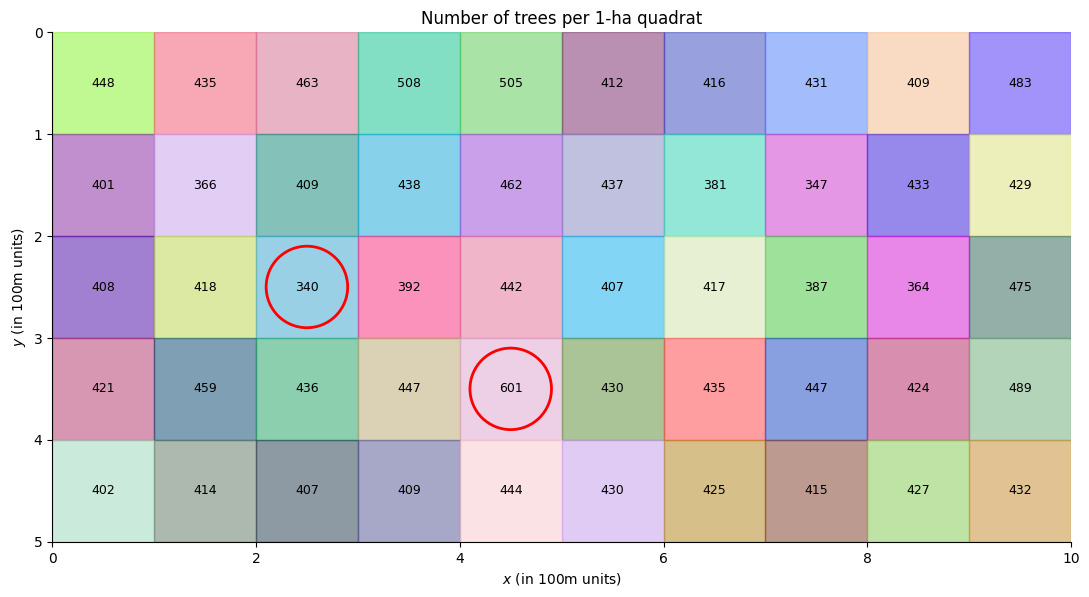

In [15]:

def plot_quadrat_grid(values, title):
    grid = values.reshape(grid_shape)
    vmin, vmax = grid.min(), grid.max()
    fig, ax = plt.subplots(figsize=(11, 6))
    rng = np.random.default_rng(1)
    colors = rng.random((grid.size, 3))
    for yi in range(grid_shape[0]):
        for xi in range(grid_shape[1]):
            idx = yi * grid_shape[1] + xi
            v = grid[yi, xi]
            ax.add_patch(mpatches.Rectangle((xi, yi), 1, 1, color=colors[idx], alpha=0.5))
            ax.text(xi + 0.5, yi + 0.5, f"{v:.0f}", ha="center", va="center", fontsize=9)
            if v in (vmin, vmax):
                ax.add_patch(mpatches.Circle((xi + 0.5, yi + 0.5), 0.4, fill=False, edgecolor="red", linewidth=2))
    ax.set_xlim(0, grid_shape[1]); ax.set_ylim(0, grid_shape[0])
    ax.set_xlabel("$x$ (in 100m units)"); ax.set_ylabel("$y$ (in 100m units)")
    ax.set_aspect("equal")
    ax.invert_yaxis()
    ax.set_title(title)
    plt.tight_layout()

plot_quadrat_grid(counts_per_plot, "Number of trees per 1-ha quadrat")


### 4.2 Species richness per quadrat

Same layout, number of distinct species present in each quadrat.


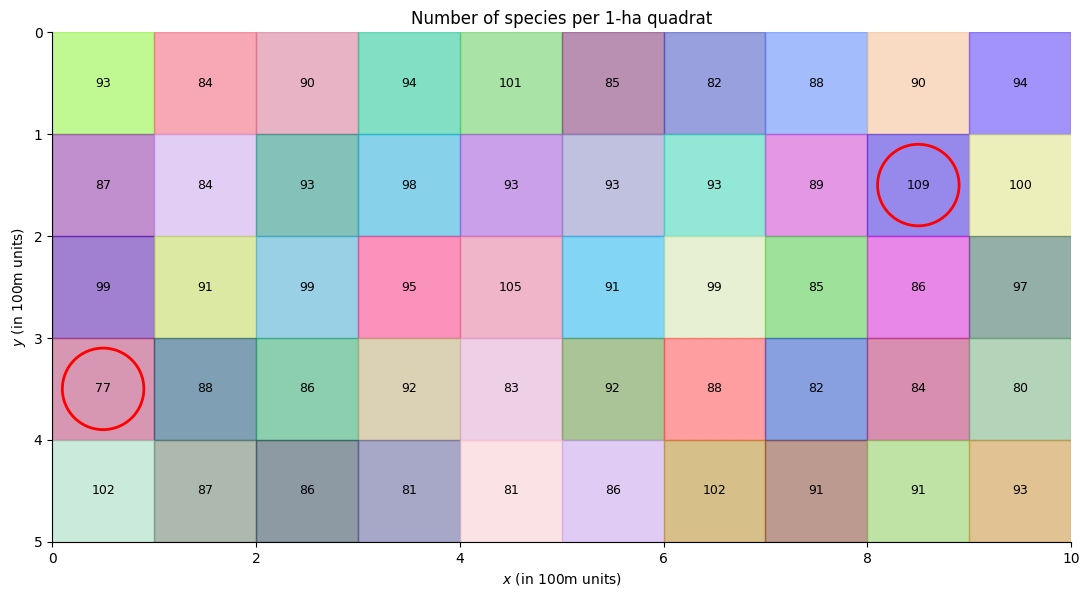

In [16]:

plot_quadrat_grid(richness_per_plot, "Number of species per 1-ha quadrat")


### 4.3 Individual-based rarefaction

As more individual trees are sampled (pooled across quadrats, without
regard to location), how many distinct species have been seen? Simulated
by repeatedly drawing random individual-level samples, alongside
Hurlbert's (1971) exact rarefaction formula for the expected count.


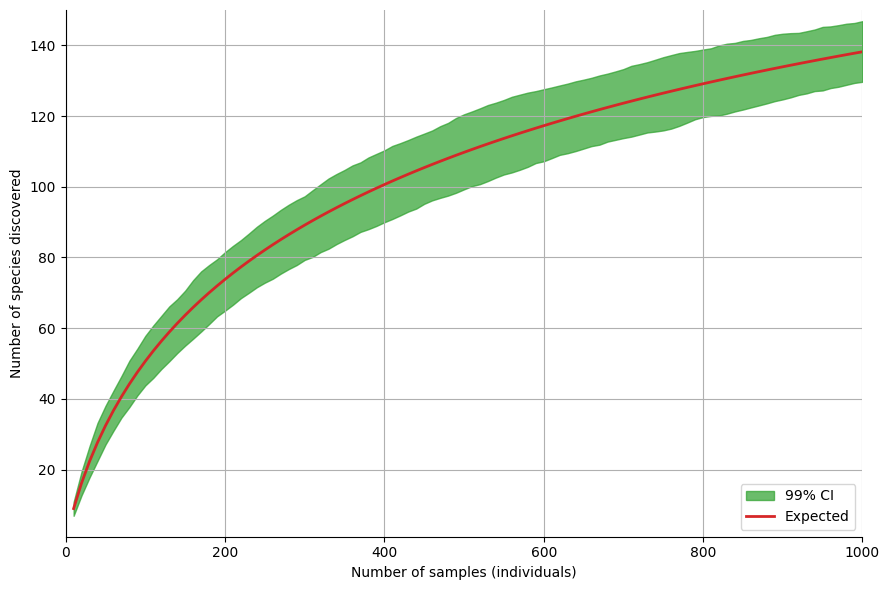

In [17]:

n_i_50 = data_bci50.sum(axis=1)
n_i_50 = n_i_50[n_i_50 > 0]

n_max_sample = 1000
species_ids = np.repeat(np.arange(len(n_i_50)), n_i_50.astype(int))

rng = np.random.default_rng(1)
n_sim = 100
sample_counts = np.zeros((n_max_sample, n_sim))
for sim in range(n_sim):
    perm = rng.permutation(species_ids)
    seen = set()
    for m in range(n_max_sample):
        seen.add(perm[m])
        sample_counts[m, sim] = len(seen)

sac_mean = sample_counts.mean(axis=1)
sac_std = sample_counts.std(axis=1)
sac_lo, sac_hi = sac_mean - 1.96 * sac_std, sac_mean + 1.96 * sac_std

m_grid = np.arange(10, n_max_sample + 1, 10)
sac_theoretical = np.array([hurlbert_rarefaction(n_i_50, m) for m in m_grid])

fig, ax = plt.subplots(figsize=(9, 6))
ax.fill_between(m_grid, sac_lo[m_grid - 1], sac_hi[m_grid - 1], color="tab:green", alpha=0.7, label="99% CI")
ax.plot(m_grid, sac_theoretical, color="tab:red", linewidth=2, label="Expected")
ax.set_xlabel("Number of samples (individuals)")
ax.set_ylabel("Number of species discovered")
ax.set_xlim(0, 1000)
ax.set_ylim(1, 150)
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()


### 4.4 Plot-based rarefaction, extrapolated

Rather than sampling individuals, sample whole quadrats and track
cumulative species richness -- alongside the Chao2 richness estimator
(which corrects for as-yet-unseen species using the count of species seen
in exactly one or two quadrats) and an extrapolated saturating-curve fit
projecting richness beyond the 50 sampled quadrats.


Fitted (asymptotic richness, rate, shape): [241.213   0.56    0.52 ]
Extrapolated richness at 1560 plots: 241.21261676932943


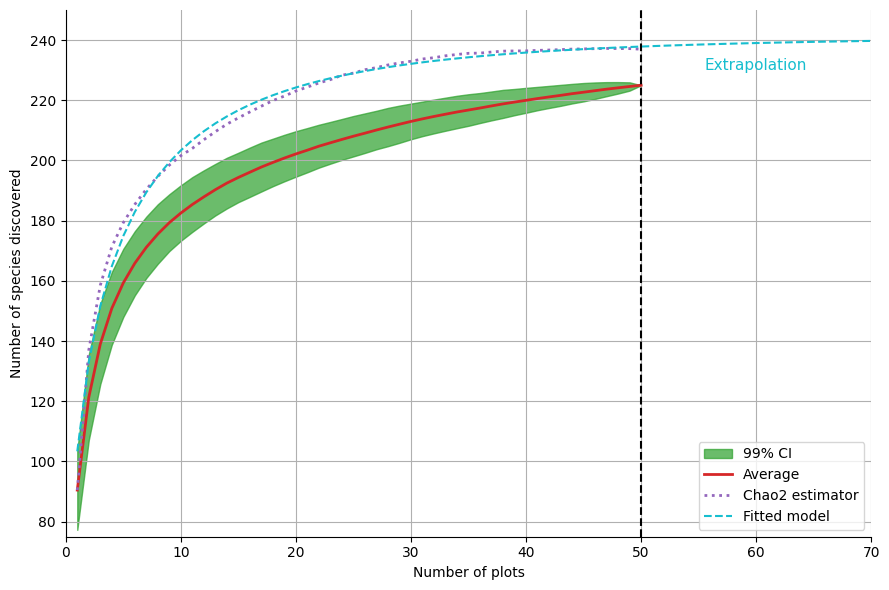

In [18]:

rng = np.random.default_rng(12345)
n_plots = data_bci50.shape[1]
n_sim = 1000
species_acc = np.zeros((n_plots, n_sim))
chao2_acc = np.full((n_plots, n_sim), np.nan)

for sim in range(n_sim):
    perm = rng.permutation(n_plots)
    cum = np.zeros(data_bci50.shape[0])
    for m in range(n_plots):
        cum += data_bci50[:, perm[m]]
        S_obs = (cum > 0).sum()
        species_acc[m, sim] = S_obs
        q1 = (cum == 1).sum()
        q2 = (cum == 2).sum()
        chao2_acc[m, sim] = S_obs + ((m) / (m + 1)) * (q1 * (q1 - 1)) / (2 * (q2 + 1))

sac_mean = species_acc.mean(axis=1)
sac_std = species_acc.std(axis=1)
sac_lo, sac_hi = sac_mean - 1.96 * sac_std, sac_mean + 1.96 * sac_std
sac_chao2 = chao2_acc.mean(axis=1)

from scipy.optimize import minimize

def rss(theta, sac):
    m = np.arange(1, len(sac) + 1)
    y = theta[0] * (1 - np.exp(-theta[1] * m ** theta[2]))
    return np.sum((y - sac) ** 2)

res = minimize(rss, x0=[250, 0.2, 1], args=(sac_chao2,), method="Nelder-Mead")
theta = res.x
print("Fitted (asymptotic richness, rate, shape):", theta.round(3))
print("Extrapolated richness at 1560 plots:", theta[0] * (1 - np.exp(-theta[1] * 1560 ** theta[2])))

x = np.arange(1, n_plots + 1)
x_extrap = np.arange(1, 71)
y_extrap = theta[0] * (1 - np.exp(-theta[1] * x_extrap ** theta[2]))

fig, ax = plt.subplots(figsize=(9, 6))
ax.fill_between(x, sac_lo, sac_hi, color="tab:green", alpha=0.7, label="99% CI")
ax.plot(x, sac_mean, color="tab:red", linewidth=2, label="Average")
ax.plot(x, sac_chao2, ":", color="tab:purple", linewidth=2, label="Chao2 estimator")
ax.plot(x_extrap, y_extrap, "--", color="tab:cyan", linewidth=1.5, label="Fitted model")
ax.axvline(50, linestyle="--", color="black", linewidth=1.5)
ax.text(60, 230, "Extrapolation", color="tab:cyan", fontsize=11, ha="center")
ax.set_xlabel("Number of plots")
ax.set_ylabel("Number of species discovered")
ax.set_xlim(0, 70)
ax.set_ylim(75, 250)
ax.legend(loc="lower right")
ax.grid(True)
plt.tight_layout()


## 5. Species-area and endemics-area relationships by model family

Given a total area $A$ containing $S$ species and $n$ individuals, how
many species (species-area, SAR) or species found *only* in a sub-area
$a$ (endemics-area, EAR) are expected as $a$ shrinks from $A$ toward zero
-- shown for five classic abundance-distribution shapes (even,
broken-stick, geometric, log-series, uneven) plus an empirical blend of
broken-stick and geometric, calibrated to a real Malaysian forest plot
(Pasoh, $S=814$ species, $n=335{,}356$ trees). Each model has its own
closed-form SAR/EAR expression, which is what is actually plotted below.


In [19]:

S, n = 814, 335_356
A = 500_000  # m^2

p_grid = np.concatenate([np.arange(0, 1e-5, 1e-6), np.arange(1e-5, 1e-4, 1e-5),
                          np.arange(1e-4, 1e-3, 1e-4), np.arange(1e-3, 1e-2, 1e-3),
                          np.arange(1e-2, 1e-1, 1e-2), np.arange(1e-1, 1.0, 1e-1)])
a_marks = np.round(np.exp(np.arange(4, 13)), 5)
a_grid = np.unique(np.concatenate([p_grid * A, a_marks]))
mark_idx = np.searchsorted(a_grid, a_marks)

# Even model
S1_sar = S * (1 - (1 - a_grid / A) ** (n / S))
S1_ear = S * (a_grid / A) ** (n / S)

# Broken-stick (a_grid includes 0, so log(0) legitimately gives -inf here --
# harmless, clipped by axis limits)
with np.errstate(divide="ignore"):
    S2_sar = S * np.log(1 - a_grid / A) / (np.log(1 - a_grid / A) - S / n)
    S2_ear = -S ** 2 / (n * np.log(a_grid / A) - S)

# Geometric (self-consistent: SAR = EAR for this model)
S3_sar = S3_ear = None  # computed via general formula below

kappa = 0.009927
i = np.arange(1, S + 1)
n_i_geom = n * kappa * (1 - kappa) ** (i - 1) / (1 - (1 - kappa) ** S)
S3_sar = species_area_relationship(n_i_geom, None, A, a_grid)
S3_ear = endemics_area_relationship(n_i_geom, None, A, a_grid)

# Log-series
alpha_ls, x_ls = 100.3014, 0.999701
S4_sar = alpha_ls * np.log(1 + x_ls * a_grid / A / (1 - x_ls))
S4_ear = -alpha_ls * np.log(1 - x_ls * a_grid / A)

# Uneven model (S-1 singletons, one dominant species)
S5_sar = 1 + (S - 1) * (a_grid / A) + (1 - a_grid / A) ** (n - S + 1)
S5_ear = (S - 1) * (a_grid / A) + (a_grid / A) ** (n - S + 1)

# Empirical blend (broken-stick / geometric)
blend = 0.4
S6_sar = blend * S2_sar + (1 - blend) * S3_sar
S6_ear = blend * S2_ear + (1 - blend) * S3_ear

models = ["Even", "Broken-stick", "Geometric", "Log-series", "Uneven", "Pasoh forest"]


### 5.1 Species-area curves

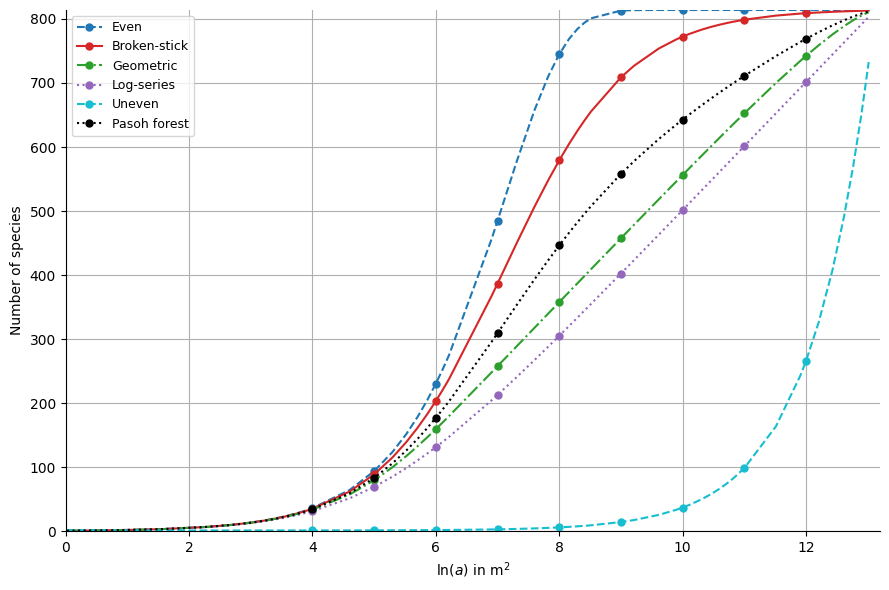

In [20]:

sar_curves = [S1_sar, S2_sar, S3_sar, S4_sar, S5_sar, S6_sar]
styles = ["--", "-", "-.", ":", "--", ":"]
colors = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:cyan", "black"]
with np.errstate(divide="ignore"):
    x = np.log(a_grid)  # a_grid[0]=0 -> -inf, clipped by xlim below

fig, ax = plt.subplots(figsize=(9, 6))
for curve, style, color, label in zip(sar_curves, styles, colors, models):
    ax.plot(x, curve, style, color=color, marker="o", markevery=list(mark_idx), markersize=5, label=label)
ax.set_xlabel(r"$\ln(a)$ in m$^2$")
ax.set_ylabel("Number of species")
ax.set_xlim(0, 13.2)
ax.set_ylim(0, 814)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()


### 5.2 Endemics-area curves


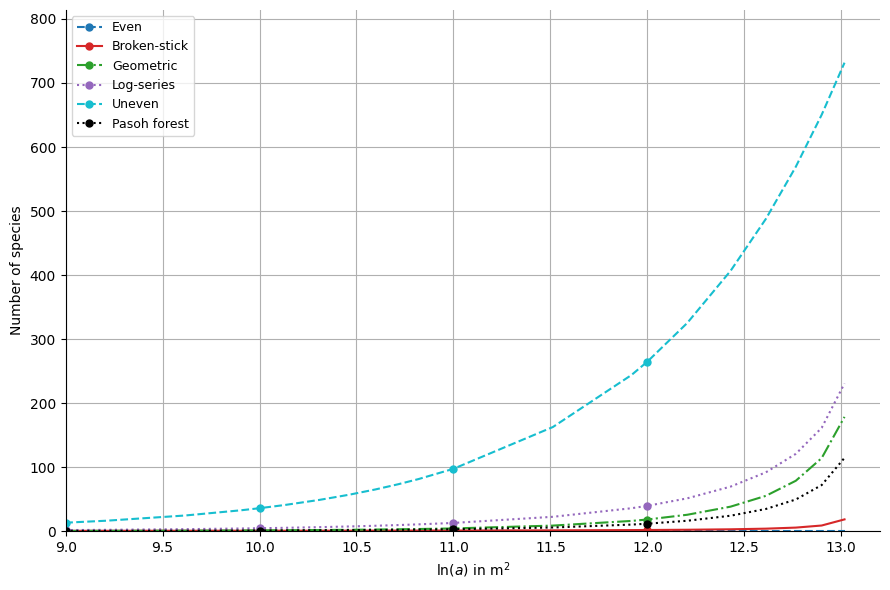

In [21]:

ear_curves = [S1_ear, S2_ear, S3_ear, S4_ear, S5_ear, S6_ear]
with np.errstate(divide="ignore"):
    x = np.log(a_grid) / np.log(np.e)

fig, ax = plt.subplots(figsize=(9, 6))
for curve, style, color, label in zip(ear_curves, styles, colors, models):
    ax.plot(x, curve, style, color=color, marker="o", markevery=list(mark_idx), markersize=5, label=label)
ax.set_xlabel(r"$\ln(a)$ in m$^2$")
ax.set_ylabel("Number of species")
ax.set_xlim(9, 13.2)
ax.set_ylim(0, 814)
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()


## 6. Testing the species-area/endemics-area relationships against real data

The theoretical (random-placement) and empirical (simulated resampling)
SAR/EAR curves for the BCI 50-quadrat plot, against two fitted power-law
approximations at different $z$ exponents.


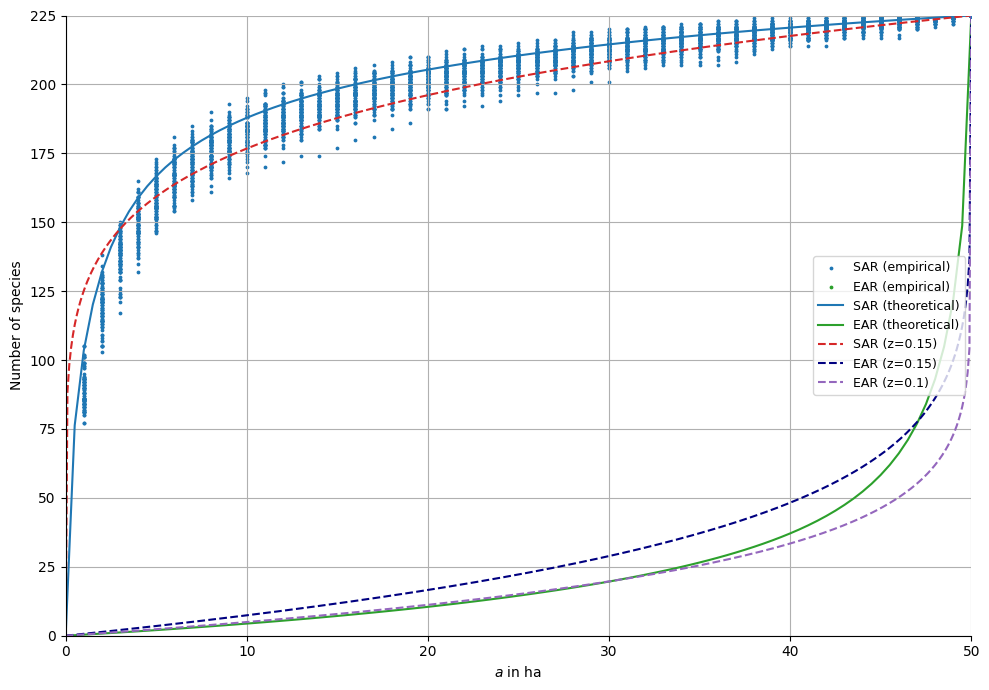

In [22]:

n_i_50 = data_bci50.sum(axis=1)
n_i_50 = n_i_50[n_i_50 > 0]
S = len(n_i_50)

A = 50  # hectares
a_grid2 = np.arange(0, 50.01, 0.5)
S1 = species_area_relationship(n_i_50, None, A, a_grid2)
E1 = endemics_area_relationship(n_i_50, None, A, a_grid2)

rng = np.random.default_rng(12345)
n_sim = 100
S_sim = np.zeros((50, n_sim))
E_sim = np.zeros((50, n_sim))
for sim in range(n_sim):
    perm = rng.permutation(50)
    for m in range(1, 51):
        included = data_bci50[:, perm[:m]]
        S_sim[m - 1, sim] = (included.sum(axis=1) > 0).sum()
        excluded = data_bci50[:, perm[m - 1:]]
        E_sim[m - 1, sim] = (excluded.sum(axis=1) == 0).sum()

a3 = np.arange(0, 50.1, 0.1)
z1 = 0.150
S3 = S * (a3 / A) ** z1
E3 = S - S * (1 - a3 / A) ** z1

z2 = 0.10
S4 = S * (a3 / A) ** z2
E4 = S - S * (1 - a3 / A) ** z2

fig, ax = plt.subplots(figsize=(10, 7))
a_plots = np.tile(np.arange(1, 51), n_sim)
ax.scatter(a_plots, S_sim.flatten(order="F"), s=3, color="tab:blue", label="SAR (empirical)")
ax.scatter(a_plots, E_sim.flatten(order="F"), s=3, color="tab:green", label="EAR (empirical)")
ax.plot(a_grid2, S1, color="tab:blue", linewidth=1.5, label="SAR (theoretical)")
ax.plot(a_grid2, E1, color="tab:green", linewidth=1.5, label="EAR (theoretical)")
ax.plot(a3, S3, "--", color="tab:red", linewidth=1.5, label=f"SAR (z={z1})")
ax.plot(a3, E3, "--", color="navy", linewidth=1.5, label=f"EAR (z={z1})")
ax.plot(a3, E4, "--", color="tab:purple", linewidth=1.5, label=f"EAR (z={z2})")
ax.set_xlabel("$a$ in ha")
ax.set_ylabel("Number of species")
ax.set_xlim(0, A)
ax.set_ylim(0, S)
ax.legend(fontsize=9, loc="center right")
ax.grid(True)
plt.tight_layout()
